# 🤖 **Impact of AI on Students**

A comprehensive dataset capturing how Generative AI tool usage shapes student performance, skill development, mental health, and burnout risk across 50,000 students. This dataset provides a rich, multi-dimensional snapshot of student interactions with AI — spanning academic outcomes, behavioral patterns, institutional context, and psychological well-being.

This dataset supports a wide range of analysis and modelling tasks:

* **GPA Change Analysis — How does AI usage correlate with academic improvement or decline? ✅**
*  Burnout Prediction — Build a classifier to predict Burnout_Risk_Level from study and AI habits.
*  Skill Retention Modelling — Does heavy AI reliance hurt long-term knowledge retention?
*  Policy Impact Study — Compare student outcomes under different institutional AI policies.
*  Mental Health Insights — Explore links between AI dependency, anxiety, and burnout.
*  Major & Year-wise Trends — Which disciplines benefit most (or suffer most) from AI adoption?

## **Dataset Overview**

| Category | Property / Column | Type | Details / Range | Description |
| :--- | :--- | :--- | :--- | :--- |
| **Metadata** | **Rows** | - | 50,000 students | Total records in the dataset. |
| | **Columns** | - | 16 features | Total dimensions tracked. |
| | **Missing Values**| - | None | Fully complete dataset. |
| | **File Format** | - | CSV | - |
| **Identifier** | `Student_ID` | Integer | 100001 – 150000 | Unique numeric identifier for each student. |
| **Academic Profile**| `Major_Category` | Categorical| STEM, Business, Humanities, Medical, Arts | Student's field of study. |
| | `Year_of_Study` | Categorical| Freshman, Sophomore, Junior, Senior, Graduate | Academic standing. |
| | `Pre_Semester_GPA` | Float | 1.18 – 4.00 | GPA at the start of the semester. |
| | `Post_Semester_GPA`| Float | 1.00 – 4.00 | GPA at the end of the semester (*Target Variable*). |
| **AI Usage** | `Weekly_GenAI_Hours`| Float | 0.00 – 40.00 hrs | Average weekly hours spent using Generative AI tools. |
| | `Primary_Use_Case` | Categorical| Copywriting, Summarizing, Debugging, Ideation... | Main purpose for using AI tools. |
| | `Prompt_Engineering_Skill`| Categorical| Beginner, Intermediate, Advanced | Student's self-assessed prompting proficiency. |
| | `Tool_Diversity` | Integer | 1 – 5 | Number of distinct AI tools actively used. |
| | `Paid_Subscription`| Boolean | True / False | Whether the student holds a paid AI subscription. |
| **Study Behavior** | `Traditional_Study_Hours`| Float | 1.00 – 35.86 hrs | Weekly hours spent studying *without* AI assistance. |
| | `Perceived_AI_Dependency`| Integer | 1 – 10 | Self-rated dependency scale (1 = low, 10 = high). |
| **Institutional Context**| `Institutional_Policy`| Categorical| Allowed_With_Citation, Strictly_Ban, Encouraged | The institution's official stance on AI usage. |
| **Well-being** | `Anxiety_Level` | Integer | 1 – 10 | Self-reported exam anxiety (1 = minimal, 10 = severe).|
| | `Skill_Retention_Score`| Float | 10.78 – 100.00 | Measures skill retention post-semester (*Target Variable*).|
| | `Burnout_Risk_Level`| Categorical| Low, Medium, High | Assessed burnout risk (*Target Variable*). |

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
from matplotlib import pyplot as plt

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/laveshjadon/ai-impact-on-students/ai_student_impact_dataset (1).csv


# **Dataset Exploration and Preprocessing**

In [2]:
dataset = pd.read_csv('/kaggle/input/datasets/laveshjadon/ai-impact-on-students/ai_student_impact_dataset (1).csv')
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  50000 non-null  int64  
 1   Major_Category              50000 non-null  object 
 2   Year_of_Study               50000 non-null  object 
 3   Pre_Semester_GPA            50000 non-null  float64
 4   Weekly_GenAI_Hours          50000 non-null  float64
 5   Primary_Use_Case            50000 non-null  object 
 6   Prompt_Engineering_Skill    50000 non-null  object 
 7   Tool_Diversity              50000 non-null  int64  
 8   Paid_Subscription           50000 non-null  bool   
 9   Traditional_Study_Hours     50000 non-null  float64
 10  Perceived_AI_Dependency     50000 non-null  int64  
 11  Institutional_Policy        50000 non-null  object 
 12  Anxiety_Level_During_Exams  50000 non-null  int64  
 13  Post_Semester_GPA           500

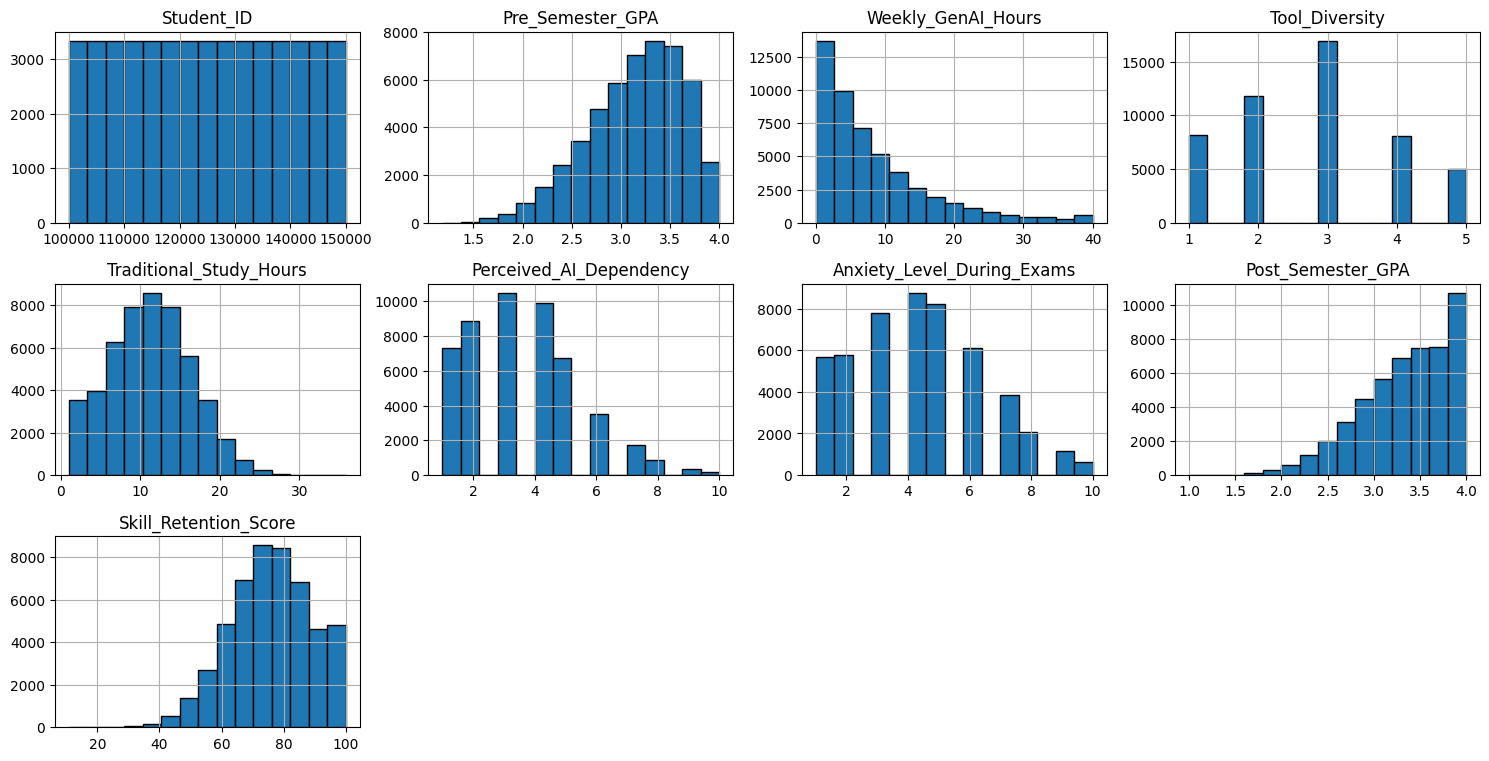

In [3]:
dataset.hist(bins=15, figsize=(15, 10), layout=(4, 4), edgecolor='black')

plt.tight_layout()
plt.show()

/tmp/ipykernel_58/732993137.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


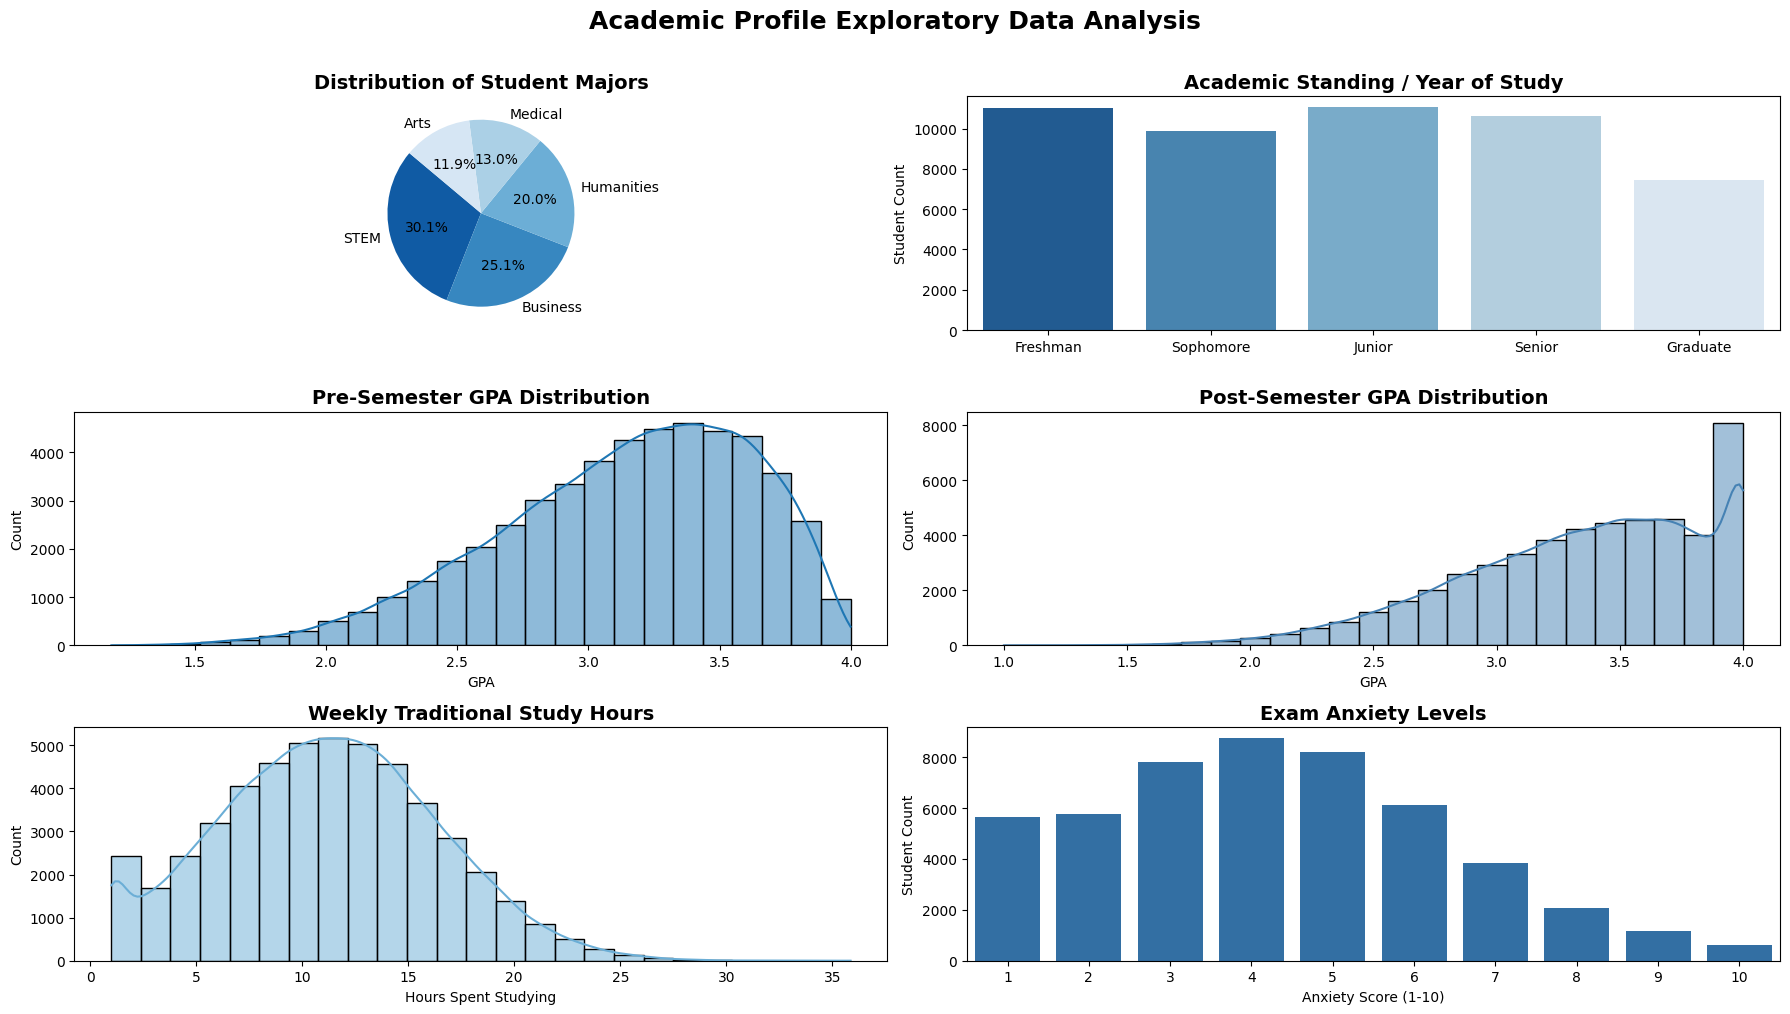

In [4]:
# Academic Profile Exploratory Data Analysis

meaningful_cols = [
    'Major_Category', 'Year_of_Study', 
    'Pre_Semester_GPA', 'Post_Semester_GPA', 
    'Traditional_Study_Hours', 'Anxiety_Level_During_Exams'
]

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(18, 10))
axes = axes.flatten()

# Student Major Data (Categorical Pie Chart)
major_counts = dataset['Major_Category'].value_counts()
axes[0].pie(
    major_counts, 
    labels=major_counts.index, 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=sns.color_palette("Blues_r", len(major_counts))
)

axes[0].set_title('Distribution of Student Majors', fontsize=14, fontweight='bold')

# Year of Study for Students (Categorical Representation)
sns.countplot(
    data=dataset, 
    x='Year_of_Study', 
    ax=axes[1], 
    palette='Blues_r',
    order=['Freshman', 'Sophomore', 'Junior', 'Senior', 'Graduate']
)
axes[1].set_title('Academic Standing / Year of Study', fontsize=14, fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('Student Count')

# Pre-Semester and Post-Semester GPA data
sns.histplot(
    data=dataset, 
    x='Pre_Semester_GPA', 
    kde=True, 
    ax=axes[2], 
    color='#1f77b4', 
    bins=25
)
axes[2].set_title('Pre-Semester GPA Distribution', fontsize=14, fontweight='bold')
axes[2].set_xlabel('GPA')

sns.histplot(
    data=dataset, 
    x='Post_Semester_GPA', 
    kde=True, 
    ax=axes[3], 
    color='#4682b4', 
    bins=25
)
axes[3].set_title('Post-Semester GPA Distribution', fontsize=14, fontweight='bold')
axes[3].set_xlabel('GPA')

# Traditional Study Hours Distribution
sns.histplot(
    data=dataset, 
    x='Traditional_Study_Hours', 
    kde=True, 
    ax=axes[4], 
    color='#6baed6', 
    bins=25
)
axes[4].set_title('Weekly Traditional Study Hours', fontsize=14, fontweight='bold')
axes[4].set_xlabel('Hours Spent Studying')

# Anxiety Level during Examinations (Scale Plot)
sns.countplot(
    data=dataset, 
    x='Anxiety_Level_During_Exams', 
    ax=axes[5], 
    color='#2171b5'
)
axes[5].set_title('Exam Anxiety Levels', fontsize=14, fontweight='bold')
axes[5].set_xlabel('Anxiety Score (1-10)')
axes[5].set_ylabel('Student Count')

plt.suptitle('Academic Profile Exploratory Data Analysis', fontsize=18, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

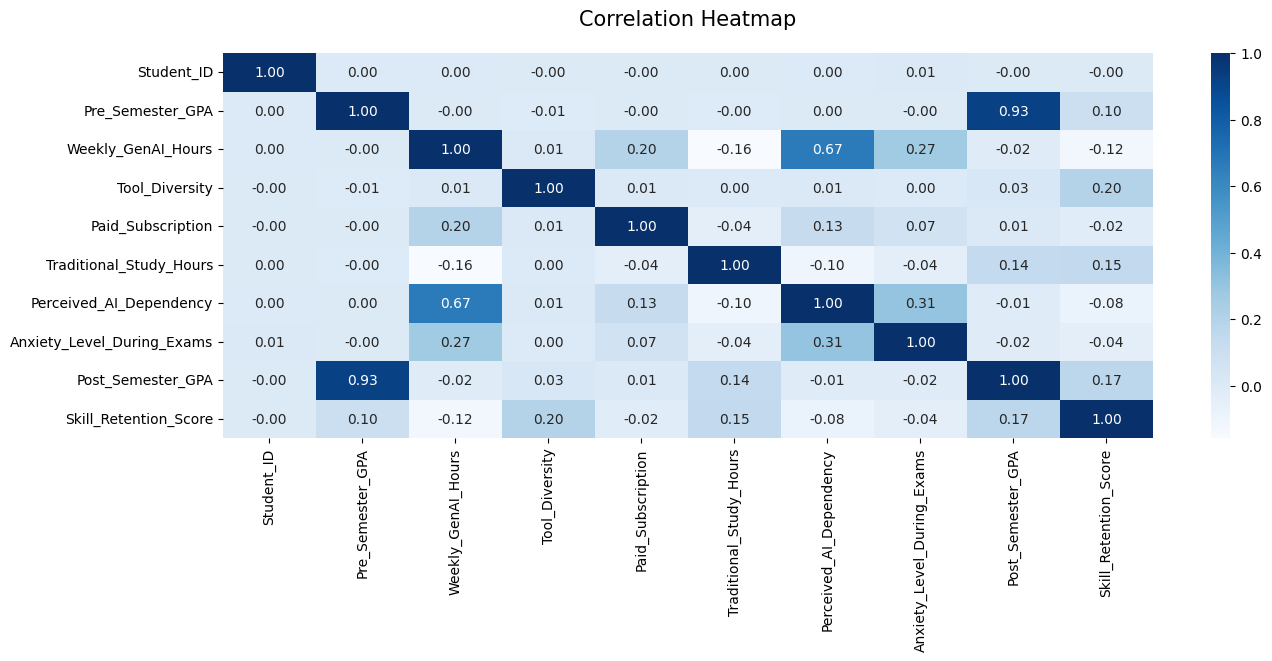

In [7]:
corr_matrix = dataset.corr(numeric_only=True)

plt.figure(figsize=(15, 5))

sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="Blues")

plt.title("Correlation Heatmap", fontsize=15, pad=20)
plt.show()

### **Dataset Exploration Goal :**
#### **How does AI usage correlate with academic improvement or decline? ✅**

* **Main Prediction Column :** Post Semester GPA
* **Affecting Factors (Columns) :**
  * Weekly Gen AI Hours
  * Paid Subscriptions
  * Traditional Study Hours
  * Tool Diversity
  * Prompt Engineering Skill
  * Perceived AI Dependency

### **Hypothesis and Data Exploration Points**
- Affecting factor's correlations to Post Semester GPA
- Feature Engineering for categorical data types
- Regression Problem : Predict the academic improvement or decline using Post Semester GPA based on AI Usage and other factors

In [8]:
categorical_cols = dataset.select_dtypes(include=['object', 'category', 'bool']).columns

print("Categorical Columns in Dataset:")
print(list(categorical_cols))

for col in categorical_cols:
    print("\n")
    print(col.upper())
    print("-"*40)
    
    print(dataset[col].value_counts(normalize=False))

Categorical Columns in Dataset:
['Major_Category', 'Year_of_Study', 'Primary_Use_Case', 'Prompt_Engineering_Skill', 'Paid_Subscription', 'Institutional_Policy', 'Burnout_Risk_Level']


MAJOR_CATEGORY
----------------------------------------
Major_Category
STEM          15059
Business      12538
Humanities     9994
Medical        6476
Arts           5933
Name: count, dtype: int64


YEAR_OF_STUDY
----------------------------------------
Year_of_Study
Junior       11045
Freshman     11031
Senior       10634
Sophomore     9860
Graduate      7430
Name: count, dtype: int64


PRIMARY_USE_CASE
----------------------------------------
Primary_Use_Case
Debugging/Troubleshooting    12295
Copywriting/Drafting         12011
Ideation                     10721
Summarizing_Reading           8633
Direct_Answer_Generation      6340
Name: count, dtype: int64


PROMPT_ENGINEERING_SKILL
----------------------------------------
Prompt_Engineering_Skill
Beginner        18495
Intermediate    17696
Advanced   

# **Feature Engineering + Final EDA Sprint**

In [9]:
df_engineered = dataset.copy()

# 1. Target column (isolating academic change)
df_engineered['GPA_Growth'] = df_engineered['Post_Semester_GPA'] - df_engineered['Pre_Semester_GPA']

# 2. Ordinal mapping (preserving order)
df_engineered['Prompt_Engineering_Skill_Encoded'] = df_engineered['Prompt_Engineering_Skill'].map(
    {'Beginner': 0, 'Intermediate': 1, 'Advanced': 2}
)
df_engineered['Burnout_Risk_Level_Encoded'] = df_engineered['Burnout_Risk_Level'].map(
    {'Low': 0, 'Medium': 1, 'High': 2}
)
df_engineered['Year_of_Study_Encoded'] = df_engineered['Year_of_Study'].map(
    {'Freshman': 0, 'Sophomore': 1, 'Junior': 2, 'Senior': 3, 'Graduate': 4}
)

# 3. Binary boolean to integer
df_engineered['Paid_Subscription_Encoded'] = df_engineered['Paid_Subscription'].astype(int)

# 4. Nominal variables (one-hot encoding)
nominal_cols = ['Major_Category', 'Primary_Use_Case', 'Institutional_Policy']
df_engineered = pd.get_dummies(df_engineered, columns=nominal_cols, drop_first=True, dtype=int)

# 5. Drop raw string equivalents and sequential ID noise
cols_to_drop = ['Student_ID', 'Prompt_Engineering_Skill', 'Burnout_Risk_Level', 'Year_of_Study', 'Paid_Subscription']
df_ml_ready = df_engineered.drop(columns=cols_to_drop, errors='ignore')

print(f"Feature engineering complete. Prepared shape: {df_ml_ready.shape}")

Feature engineering complete. Prepared shape: (50000, 23)


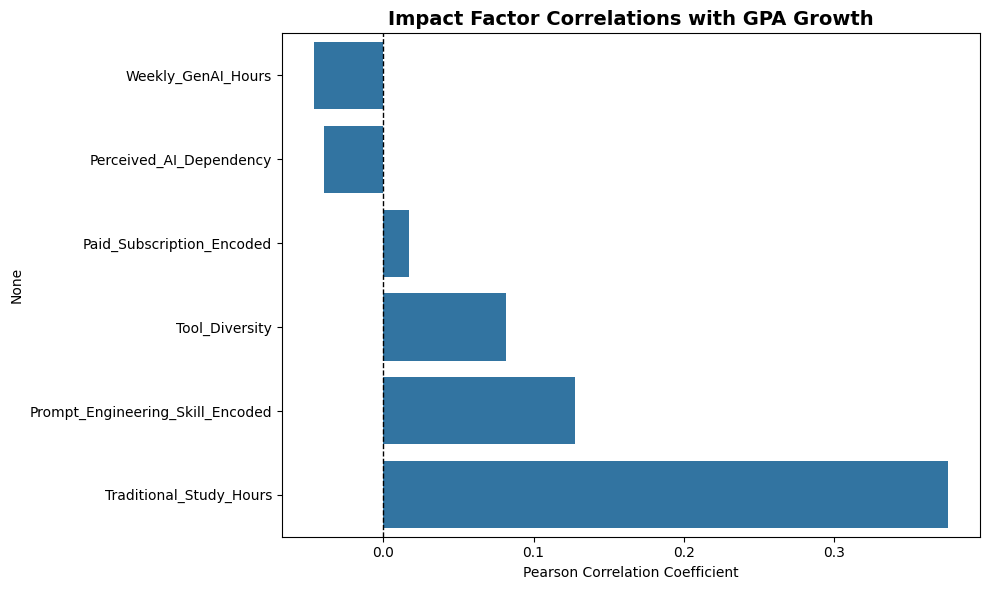

In [10]:
target_factors = [
    'Weekly_GenAI_Hours', 'Paid_Subscription_Encoded', 
    'Traditional_Study_Hours', 'Tool_Diversity', 
    'Prompt_Engineering_Skill_Encoded', 'Perceived_AI_Dependency'
]

growth_corr = df_ml_ready[target_factors].corrwith(df_ml_ready['GPA_Growth']).sort_values()

plt.figure(figsize=(10, 6))
sns.barplot(x=growth_corr.values, y=growth_corr.index)

plt.title('Impact Factor Correlations with GPA Growth', fontsize=14, fontweight='bold')
plt.xlabel('Pearson Correlation Coefficient')
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
plt.tight_layout()
plt.show()

/tmp/ipykernel_58/2429506910.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_58/2429506910.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Beginner', 'Intermediate', 'Advanced'])
/tmp/ipykernel_58/2429506910.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_58/2429506910.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['Beginner', 'Intermediate', 'Advanced'])


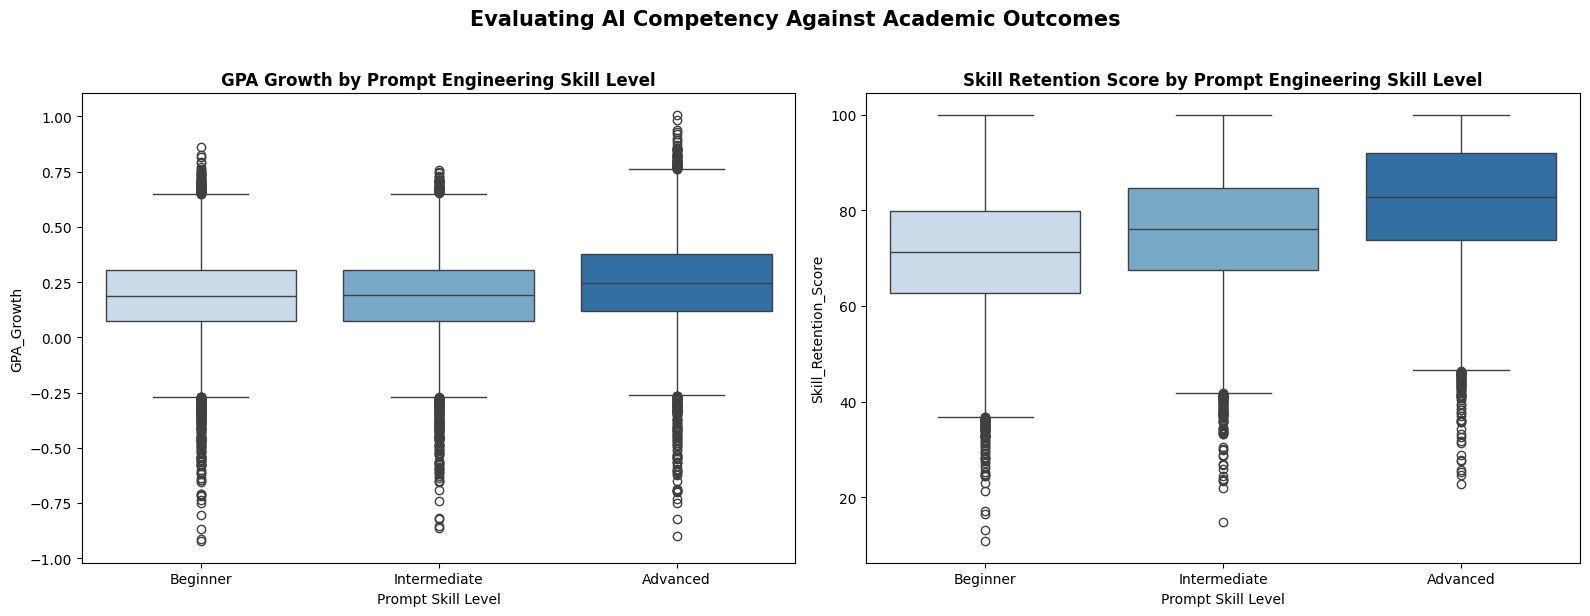

In [11]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 6))

# Boxplot for GPA Growth across Prompting Levels
sns.boxplot(
    data=df_ml_ready, 
    x='Prompt_Engineering_Skill_Encoded', 
    y='GPA_Growth', 
    ax=axes[0], 
    palette='Blues'
)
axes[0].set_title('GPA Growth by Prompt Engineering Skill Level', fontsize=12, fontweight='bold')
axes[0].set_xticklabels(['Beginner', 'Intermediate', 'Advanced'])
axes[0].set_xlabel('Prompt Skill Level')

# Boxplot for Skill Retention across Prompting Levels
sns.boxplot(
    data=df_ml_ready, 
    x='Prompt_Engineering_Skill_Encoded', 
    y='Skill_Retention_Score', 
    ax=axes[1], 
    palette='Blues'
)
axes[1].set_title('Skill Retention Score by Prompt Engineering Skill Level', fontsize=12, fontweight='bold')
axes[1].set_xticklabels(['Beginner', 'Intermediate', 'Advanced'])
axes[1].set_xlabel('Prompt Skill Level')

plt.suptitle('Evaluating AI Competency Against Academic Outcomes', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

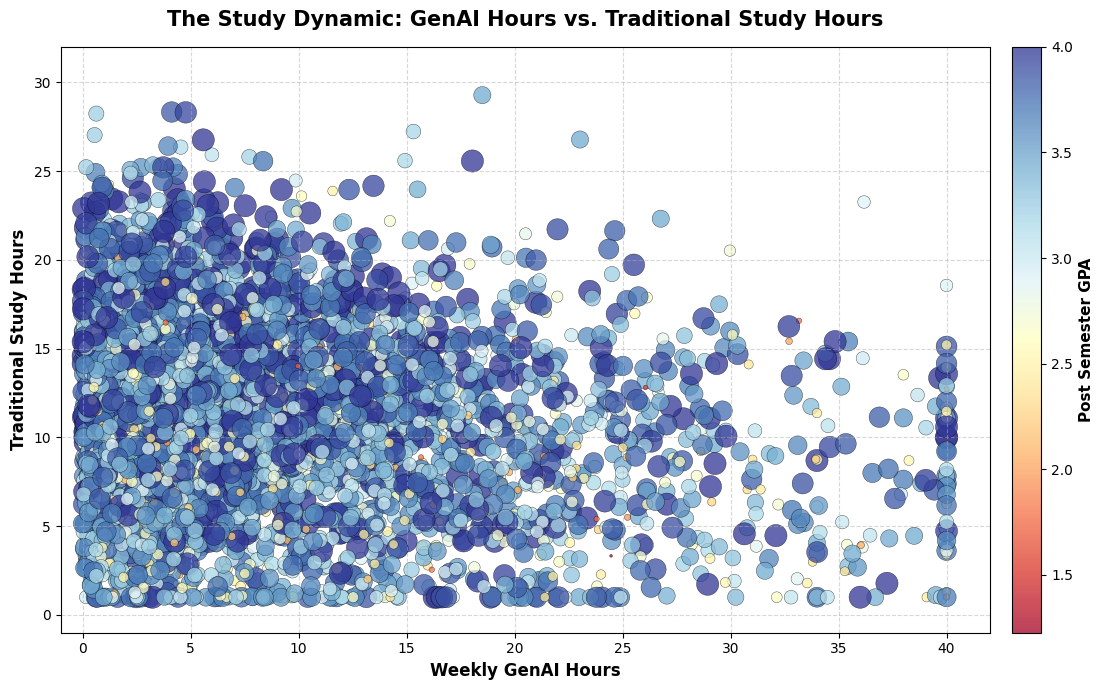

In [12]:
plt.figure(figsize=(12, 7))

df_sample = df_ml_ready.sample(n=5000, random_state=42)

point_sizes = (df_sample['Post_Semester_GPA'] ** 3.5) * 2

scatter = plt.scatter(
    data=df_sample,
    x='Weekly_GenAI_Hours',
    y='Traditional_Study_Hours',
    c='Post_Semester_GPA',
    s=point_sizes,                 # Dynamic sizing for visual weight
    cmap='RdYlBu',                 # Diverging color scheme (Red = Low, Blue = High)
    alpha=0.75,                    # Higher opacity for stronger visibility
    edgecolors='black',            # Crisp borders around dots
    linewidths=0.3
)

# Format colorbar
cbar = plt.colorbar(scatter, pad=0.02)
cbar.set_label('Post Semester GPA', fontweight='bold', fontsize=11)

# Add clear target indicators
plt.title('The Study Dynamic: GenAI Hours vs. Traditional Study Hours', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Weekly GenAI Hours', fontsize=12, fontweight='bold')
plt.ylabel('Traditional Study Hours', fontsize=12, fontweight='bold')

plt.xlim(-1, 42)
plt.ylim(-1, 32)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### **Dataset Exploration Goal :**
#### **How does AI usage correlate with academic improvement or decline? ✅**

* **Main Prediction Column :** Post Semester GPA
* **Affecting Factors (Columns) :**
  * Weekly Gen AI Hours
  * Paid Subscriptions
  * Traditional Study Hours
  * Tool Diversity
  * Prompt Engineering Skill
  * Perceived AI Dependency

#### **Final Conclusions :**
- Paid Subscriptions, Tool Diversity, Prompt Engineering Skills and Higher traditional study hours correlated very high towards GPA Growth
- Greater Prompt Engineering Skill Level lead to higher skill retention and higher GPA Growth
- Most high GPA students showcased less than 25-30 weekly GenAI Hours and greater traditional study hours

# **Machine Learning Model**

- Solves a regression problem : how does the different AI usage factors affect final GPA growth column
- Higher focus on paid subscriptions, traditional study hours, tool diversity, prompt engineering skill

## **Ridge Regression**
* **Isolating Features ($X$) and Target ($y$):** You strip away the raw benchmarks (`Pre` and `Post` GPAs) and map your focus features into $X$. Your target $y$ is exclusively the engineered `GPA_Growth`.
* **The 80/20 Train/Test Split:** `train_test_split` locks away 20% of your data (`X_test`, `y_test`) in a "vault." The model only sees the other 80% (`X_train`, `y_train`) to learn the patterns. This ensures your evaluation scores reflect how the model performs on *unseen* data.

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score

# Isolate your features and engineered target
X = df_ml_ready.drop(columns=['Post_Semester_GPA', 'Pre_Semester_GPA', 'GPA_Growth', 'Academic_Improved'], errors='ignore')
y = df_ml_ready['GPA_Growth']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Ridge handles any subtle correlations among features smoothly
model = Ridge(alpha=1.0)
model.fit(X_train, y_train)

# Evaluate
preds = model.predict(X_test)
print(f"R² Score: {r2_score(y_test, preds):.4f}")

# Extract the exact impact weights
coefficients = pd.DataFrame({'Feature': X.columns, 'Weight': model.coef_}).sort_values(by='Weight', ascending=False)
print(coefficients)

R² Score: 0.2531
                                       Feature    Weight
14  Primary_Use_Case_Debugging/Troubleshooting  0.045397
8                        Year_of_Study_Encoded  0.030753
6             Prompt_Engineering_Skill_Encoded  0.022307
2                      Traditional_Study_Hours  0.013434
9                    Paid_Subscription_Encoded  0.011062
18  Institutional_Policy_Allowed_With_Citation  0.004808
12                      Major_Category_Medical  0.004503
7                   Burnout_Risk_Level_Encoded  0.001190
11                   Major_Category_Humanities  0.001126
16                   Primary_Use_Case_Ideation  0.001070
5                        Skill_Retention_Score  0.001000
1                               Tool_Diversity  0.000535
0                           Weekly_GenAI_Hours  0.000465
13                         Major_Category_STEM -0.001209
10                     Major_Category_Business -0.001339
3                      Perceived_AI_Dependency -0.001562
4             

### **Model Performance Benchmark**

* **$R^2$ Score (0.2531):** Can be improved using further feature engineering and model construction



#### **Key Positive Drivers (What Boosts GPA Growth)**

* `Primary_Use_Case_Debugging/Troubleshooting` (+0.0454): This is the single strongest positive AI factor in the dataset. Using AI to actively fix code or problem-solve yields a bigger academic growth dividend than any other use case
* `Year_of_Study_Encoded` (+0.0308): Older or more academically advanced students (Juniors, Seniors, Graduates) achieve significantly higher GPA growth rates than fresh underclassmen when using these tools
* `Prompt_Engineering_Skill_Encoded` (+0.0223): Higher self-assessed capability in prompting translates directly into positive growth, validating that *how* a student interacts with AI dictates its academic return
* `Traditional_Study_Hours` (+0.0134) & `Paid_Subscription_Encoded` (+0.0111): Both classic studying and investing in a premium AI platform offer slight, reliable baseline boosts to a student's positive semester trajectory



#### **Key Negative Drivers (What Drags Down GPA Growth)**

* `Primary_Use_Case_Direct_Answer_Generation` (-0.0659): This is the most destructive behavioral trait in the dataset. Using generative tools as a shortcut to bypass critical thinking and print immediate answers heavily correlates with academic decline
* `Institutional_Policy_Strict_Ban` (-0.0149): Students attending universities with a strict ban on AI usage experience lower GPA growth, potentially due to a lack of safe, guided integration of these technologies
* `Primary_Use_Case_Summarizing_Reading` (-0.0041): Letting AI summarize academic literature yields a minor negative trajectory, indicating that outsourcing reading comprehension may slightly erode learning depth
* `Anxiety_Level_During_Exams` (-0.0017) & `Perceived_AI_Dependency` (-0.0016): High test anxiety and a high psychological reliance on AI both act as distinct, minor anchors dragging growth downward



#### **Neutral / Near-Zero Factors (Minimal Impact)**

* `Major_Category_STEM / Business` (~ -0.0012): Choosing a technical or business track has an almost completely negligible baseline effect on growth relative to other disciplines
* `Tool_Diversity` (+0.0005) & `Weekly_GenAI_Hours` (+0.0004): Surprisingly, the sheer volume of hours logged and the raw number of tools used have almost zero standalone impact on growth. It is entirely the *method of use* (Use Case & Skill) that moves the needle, not the volume of usage

## **Decision Trees and Random Forests**

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error, r2_score

X = df_ml_ready.drop(columns=['Post_Semester_GPA', 'Pre_Semester_GPA', 'GPA_Growth', 'Academic_Improved'], errors='ignore')
y = df_ml_ready['GPA_Growth']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
rf_model = RandomForestRegressor(n_estimators=100, max_depth=8, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"--- Model Evaluation ---")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R² Score: {r2:.4f}\n")

# Extract Feature Importances
importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("--- Feature Importances ---")
print(importances.to_string(index=False))

--- Model Evaluation ---
Root Mean Squared Error (RMSE): 0.1486
R² Score: 0.3576

--- Feature Importances ---
                                   Feature  Importance
                   Traditional_Study_Hours    0.386258
                        Weekly_GenAI_Hours    0.193629
                     Year_of_Study_Encoded    0.146075
Primary_Use_Case_Debugging/Troubleshooting    0.088053
          Prompt_Engineering_Skill_Encoded    0.075711
 Primary_Use_Case_Direct_Answer_Generation    0.054931
                     Skill_Retention_Score    0.020830
                   Perceived_AI_Dependency    0.007757
                Anxiety_Level_During_Exams    0.006340
                 Paid_Subscription_Encoded    0.005748
           Institutional_Policy_Strict_Ban    0.004830
                            Tool_Diversity    0.002615
Institutional_Policy_Allowed_With_Citation    0.001477
                Burnout_Risk_Level_Encoded    0.001397
                    Major_Category_Medical    0.001127
          

# **Conclusion & Key Takeaways**

Switching from ridge regression model to the random forest completely changes the perspective.

Here are the biggest things this analysis actually proves :

* **The Linear Illusion vs. Non-linear Reality:** When we ran the first linear model, `Weekly_GenAI_Hours` looked like it had an impact score of basically zero. But the second we plugged it into the random forest, it jumped up to become the second most important factor in the whole dataset. This tells us that the number of hours you spend using AI doesn't affect your grades in a linear fashion. It probably helps you a lot up to a certain point, but then starts hurting you if you go overboard. The linear model completely missed that curve, but the tree model caught it.

* **Behavior Over Infrastructure:** Another huge takeaway is that your actual habits matter way more than what you buy or how many apps you open. Factors like `Paid_Subscription_Encoded` and `Tool_Diversity` ended up sitting way down at the bottom of the importance list. It doesn't matter if you pay for the premium version or use five different tools at once. What actually matters is *how* you use it. For example, using AI for `Debugging/Troubleshooting` had the highest positive impact on growth, while using it for `Direct_Answer_Generation` was the absolute worst thing a student could do. It's all about active learning versus taking lazy shortcuts.

* **The Academic Anchor:** Even though this whole study is focused on new technology and AI, old-school studying is still king. `Traditional_Study_Hours` was by far the most important variable for predicting whether a student's GPA would grow or drop. AI can be a really powerful assistant if you use it correctly, but hit-the-books independent study time is still the primary engine behind a student's success.

Overall, moving to the random forest pushed our $R^2$ score from 0.25 up to 0.35. That is a massive upgrade and gives us a much more accurate, realistic look at how tech and study habits actually blend together in real life.